In [1]:
import os
import shutil
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import distance_transform_edt, gaussian_filter
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from skimage.io import imshow
from sklearn.decomposition import PCA
from skimage import measure
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.neighbors import KDTree

In [2]:
# Loads a grayscale image, binarizes it, and centers it in an SxS canvas with zero-padding
def pad_binary(path, S):
    img = np.array(Image.open(path).convert("L"))
    binary = (img > 127).astype(np.uint8)
    h, w = binary.shape
    if h > S or w > S:
        raise ValueError(f"Image ({h},{w}) is larger than target size S={S}")
    pad_top    = (S - h) // 2
    pad_bottom = S - h - pad_top
    pad_left   = (S - w) // 2
    pad_right  = S - w - pad_left
    padded = np.pad(binary,((pad_top, pad_bottom), (pad_left, pad_right)),mode='constant',constant_values=0)
    return padded

# Creates an SxS grid of (x, y) coordinates ranging from -1 to 1
def make_square_grid(S):
    xs = np.linspace(-1, 1, S)
    ys = np.linspace(-1, 1, S)
    X, Y = np.meshgrid(xs, ys)
    coords = np.stack([X, Y], axis=-1)   # (S, S, 2)
    return coords

# Flips the image vertically (to match grid orientation) and appends it as a third channel to the grid
def move_image_to_grid(set_grid, img):
    img_flipped = img[::-1, :]
    return np.concatenate([set_grid, img_flipped[..., None].astype(np.uint8)], axis=-1)

# Extracts only the "on" pixels (value > 0) and returns their (x, y) coordinates
def get_shape(bin):
    return bin[bin[:, :, 2] > 0][:, :2]

# Returns the number of "on" pixels as the shape's volume
def compute_volume(shape):
    return float(shape.shape[0])

# Computes the centroid
def compute_centroid(shape):
    V = compute_volume(shape)
    sum_x = shape[:, 0].sum()
    sum_y = shape[:, 1].sum()
    center = np.array([sum_x / V, sum_y / V])
    return center

# Computes the 2x2 covariance matrix
def compute_covariance(shape):
    V = compute_volume(shape)
    beta = compute_centroid(shape)
    coords_shift=shape-beta
    cov_mat=(coords_shift.T @ coords_shift) / V
    return cov_mat

# Returns the size of the shape as the square root of the covariance matrix's trace
def compute_size(shape):
    return float(np.sqrt(np.trace(compute_covariance(shape))))

# Computes the alignment transform (scale λ, rotation R, translation t)
# that normalizes the shape to a target size and orients it along its principal axes
def compute_alignment(shape,target_size=0.4, flip=(-1,-1)):
    beta = compute_centroid(shape)
    gamma = compute_size(shape)
    lam = target_size / gamma
    _, V = np.linalg.eigh(compute_covariance(shape))
    V = V[:, [1, 0]]
    V[:, 0] *= flip[0]
    V[:, 1] *= flip[1]
    R = V.T
    t = -lam * (R @ beta)
    return lam, R, t

def transform_on_set_grid(set_grid, img, lam, R, t):
    Ycoords = set_grid.reshape(-1, 2)
    # Map each output grid point back to source image coordinates via inverse transform
    Xquery = ((Ycoords - t) @ R) / lam
    src_coords = img[:, :, :2].reshape(-1, 2)
    src_vals   = img[:, :, 2].reshape(-1)
    # Nearest-neighbor lookup: find the closest source pixel for each transformed query point
    tree = KDTree(src_coords)
    _, idx = tree.query(Xquery, k=1)
    idx = idx[:, 0]
    sampled_vals = src_vals[idx]
    out = np.concatenate([Ycoords, sampled_vals[:, None]], axis=1)
    return out.reshape(S, S, 3)

In [3]:
# Load, align, and normalize all mask images in the dataset
# into a canonical coordinate system
S=1001
set_grid=make_square_grid(S)

mask_dir = "test1/mask"
real_dir = "test1/real"
all_real_dir = "all_real"
enc_dir = "encoding_test"
files = sorted(os.listdir(mask_dir))
num_wings = len(files)

bins = []
moved_bins = []
transformed_bins = []

for filename in files:
    bin_path = os.path.join(mask_dir, filename)
    bin = pad_binary(bin_path, S)
    moved_bin=move_image_to_grid(set_grid, bin)
    shape=get_shape(moved_bin)
    lam, R, t =compute_alignment(shape, target_size=0.4)
    transformed_bin=transform_on_set_grid(set_grid, moved_bin, lam, R, t)

    bins.append(bin)
    moved_bins.append(moved_bin)
    transformed_bins.append(transformed_bin)

In [4]:
# Computes the signed distance field (SDF) of a binary shape
# Optional root crops the left side before computing.
def compute_sdf(bin, root=None):
    coords = bin[:, :, :2]
    vals = bin[:, :, 2].copy()
    if root is not None:
        xcoords = coords[:, :, 0]
        vals[xcoords < root] = 0
    mask = vals > 0
    d = 2.0 / (S - 1)
    dist_out = distance_transform_edt(~mask, sampling=(d, d))
    dist_in  = distance_transform_edt(mask,  sampling=(d, d))
    sdf = dist_out - dist_in
    sdf_bin = np.concatenate([coords, sdf[..., None]], axis=-1)
    return sdf_bin

# Compute SDFs for raw, aligned, and root-cropped versions of all shapes
sdfs=[]
aligned_sdfs=[]
nr_aligned_sdfs=[]
for i in moved_bins:
    sdf=compute_sdf(i)
    sdfs.append(sdf)
for i in transformed_bins:
    sdf=compute_sdf(i)
    aligned_sdfs.append(sdf)
for i in transformed_bins:
    sdf=compute_sdf(i, root=-0.8)
    nr_aligned_sdfs.append(sdf)


In [5]:
# Plots the SDF as a pixel image with a diverging colormap and zero-contour line
def plot_sdf_as_image(sdf_bin):
    Z = sdf_bin[:, :, 2]
    max_abs = np.max(np.abs(Z))
    plt.figure(figsize=(10, 4))
    im = plt.imshow(Z, origin='lower', cmap='seismic',vmin=-max_abs, vmax=max_abs)
    plt.contour(Z, levels=[0], colors='black', linewidths=1.5, origin='lower')
    plt.title('SDF as image')
    plt.xlabel('j')
    plt.ylabel('i')
    plt.show()

# Plots the SDF mapped onto its actual (x, y) coordinate grid
def plot_sdf_on_coords(sdf_bin):
    X = sdf_bin[:, :, 0]
    Y = sdf_bin[:, :, 1]
    Z = sdf_bin[:, :, 2]
    max_abs = np.max(np.abs(Z))
    plt.figure(figsize=(8, 8))
    pcm = plt.pcolormesh(X, Y, Z, shading='auto', cmap='seismic',vmin=-max_abs, vmax=max_abs)
    plt.contour(X, Y, Z, levels=[0], colors='black', linewidths=1.5)
    plt.gca().set_aspect('equal')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlim(-1,1)
    plt.ylim(-1, 1)
    plt.title('SDF on coordinate system')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.colorbar(pcm)
    plt.show()

# Overlays the SDF zero-contour on top of the raw shape's scatter plot
def plot_sdf_on_bin(sdf,bin):
    X = sdf[:, :, 0]
    Y = sdf[:, :, 1]
    Z = sdf[:, :, 2]
    max_abs = np.max(np.abs(Z))
    plt.figure(figsize=(8, 8))
    bin=get_shape(bin)
    plt.scatter(bin[:, 0], bin[:, 1], s=0.5)
    plt.contour(X, Y, Z, levels=[0], colors='red', linewidths=3)
    plt.gca().set_aspect('equal')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlim(-1,1)
    plt.ylim(-1, 1)
    plt.title('SDF on coordinate system')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

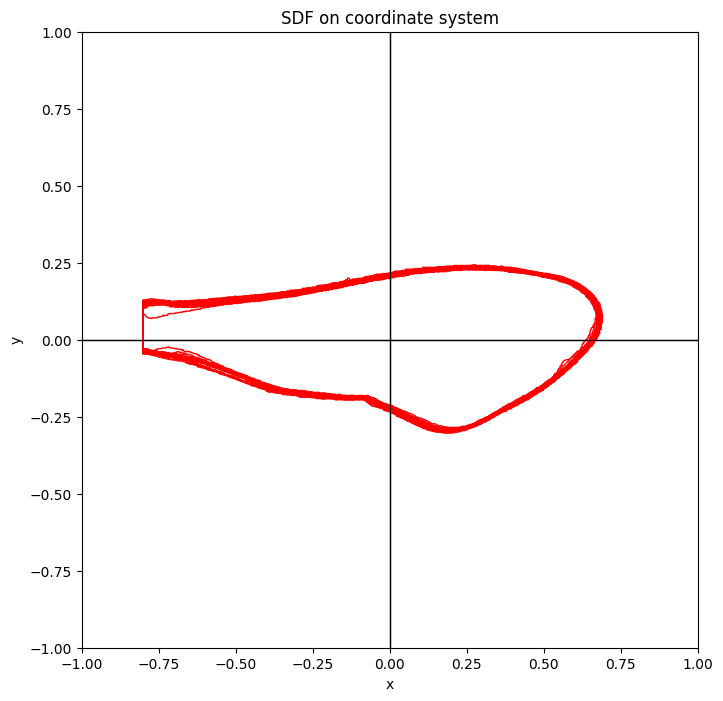

In [6]:
# Plot all aligned SDF zero-contours overlaid on the same canvas
# to visualize shape variation across the dataset
plt.figure(figsize=(8, 8))
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlim(-1,1)
plt.ylim(-1, 1)
plt.gca().set_aspect('equal')
for i in nr_aligned_sdfs:
    X = i[:, :, 0]
    Y = i[:, :, 1]
    Z = i[:, :, 2]
    plt.contour(X, Y, Z, levels=[0], colors='red', linewidths=1)
plt.gca().set_aspect('equal')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlim(-1,1)
plt.ylim(-1, 1)
plt.title('SDF on coordinate system')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


In [7]:
# Computes the pairwise L2 distance matrix between all SDFs in the list
def compute_l2_sdf_matrix(sdf_list):
    n = len(sdf_list)
    D = np.zeros((n, n))
    for i in range(n):
        Zi = sdf_list[i][:, :, 2]
        for j in range(i + 1, n):
            Zj = sdf_list[j][:, :, 2]
            d = np.sqrt(np.mean((Zi - Zj) ** 2))
            D[i, j] = d
            D[j, i] = d
    return D

# Prints the top-k closest and farthest SDF pairs based on the distance matrix
def print_extreme_pairs(D, top_k=10):
    n = D.shape[0]
    pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            pairs.append((i, j, D[i, j]))
    pairs_sorted = sorted(pairs, key=lambda x: x[2])
    print("\n=== 10 CLOSEST PAIRS ===")
    for rank, (i, j, d) in enumerate(pairs_sorted[:top_k], 1):
        print(f"{rank}. ({i}, {j}) -> distance = {d:.6f}")
    print("\n=== 10 FARTHEST PAIRS ===")
    for rank, (i, j, d) in enumerate(pairs_sorted[-top_k:][::-1], 1):
        print(f"{rank}. ({i}, {j}) -> distance = {d:.6f}")

In [8]:
D = compute_l2_sdf_matrix(nr_aligned_sdfs)

In [9]:
# Samples points from an SDF, mixing near-surface points (within epsilon of zero)
# and uniform random points across the grid

def sample_sdf_points(sdf, epsilon=0.05, num_samples=5000, percent=0.5):
    coords_vals = sdf.reshape(-1, 3)
    sdf_vals = coords_vals[:, 2]
    band_mask = np.abs(sdf_vals) < epsilon
    band_points = coords_vals[band_mask]
    all_points = coords_vals
    n_band = int(num_samples * percent)
    n_uniform = num_samples - n_band
    replace_band = len(band_points) < n_band
    band_idx = np.random.choice(len(band_points),size=n_band,replace=replace_band)
    replace_uniform = len(all_points) < n_uniform
    uniform_idx = np.random.choice(len(all_points),size=n_uniform,replace=replace_uniform)
    samples_band = band_points[band_idx]
    samples_uniform = all_points[uniform_idx]
    samples = np.concatenate([samples_band, samples_uniform], axis=0)
    np.random.shuffle(samples)
    return samples


In [ ]:
# Visualize sampled points overlaid on the SDF zero-contour
# for the first shape, to sanity-check the sampling distribution
sdf=nr_aligned_sdfs[0]

samples = sample_sdf_points(sdf,epsilon=0.07,num_samples=4000,percent=0.4)
sample_x = samples[:, 0]
sample_y = samples[:, 1]
sample_vals = samples[:, 2]  # optional (SDF values)

plt.figure(figsize=(8, 8))
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.gca().set_aspect('equal')
X = sdf[:, :, 0]
Y = sdf[:, :, 1]
Z = sdf[:, :, 2]
plt.contour(X, Y, Z, levels=[0], colors='red', linewidths=2)
plt.scatter(sample_x, sample_y,s=5,c='blue',alpha=0.6,label='Sampled points')
plt.title('SDF with sampled points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [10]:
# Dataset class that returns (shape_id, coordinate, sdf_value) tuples for each sampled point
class SDFDataset(Dataset):
  def __init__(self, dataset):
    self.data = dataset
  def __len__(self):
    return len(self.data)
  def __getitem__(self, idx):
    s = self.data[idx]
    return (
        torch.tensor(s["shape_id"], dtype=torch.long),
        torch.tensor(s["coord"], dtype=torch.float32),
        torch.tensor(s["distance"], dtype=torch.float32),
    )

# Sample points from all shapes and flatten into a single
# list of (shape_id, coord, sdf_value) records, then wrap in a DataLoader
dataset = []
for shape_idx, sdf in enumerate(nr_aligned_sdfs):
    samples = sample_sdf_points(sdf,epsilon=0.07,num_samples=4000,percent=0.4)
    coords = samples[:, :2]
    values = samples[:, 2]
    for c, v in zip(coords, values):
        dataset.append({"shape_id": shape_idx,"coord": c,"distance": v})
print("Total samples:", len(dataset))

loader = DataLoader(SDFDataset(dataset), batch_size=512, shuffle=True)

Total samples: 80000


In [11]:
# A single SIREN layer: linear transform followed by a scaled sine activation,
# with initialization tuned to the layer's position in the network
class SineLayer(nn.Module):
  def __init__(self, in_features, out_features, is_first=False, omega0=30.0):
    super().__init__()
    self.in_features = in_features
    self.is_first = is_first
    self.omega0 = omega0
    self.linear = nn.Linear(in_features, out_features)
    self.init_weights()

  def init_weights(self):
    with torch.no_grad():
      if self.is_first:
        # U(-1/n, 1/n)
        self.linear.weight.uniform_(-1 / self.in_features, 1 / self.in_features)
      else:
        # U(-sqrt(6/n)/omega0, sqrt(6/n)/omega0)
        bound = math.sqrt(6 / self.in_features) / self.omega0
        self.linear.weight.uniform_(-bound, bound)
        # Bias init usually 0 is fine; PyTorch already does something small.
        # If you want:
        # self.linear.bias.zero_()

  def forward(self, x):
    return torch.sin(self.omega0 * self.linear(x))

# Full SIREN-based DeepSDF network: takes a latent code + 2D coordinate and predicts
# the SDF value. 5 sine layers with a plain linear output head
class SirenDeepSDF2D(nn.Module):
  def __init__(self, latent_dim=16, hidden_dim=256, omega0_first=30.0, omega0_hidden=60.0):
    super().__init__()
    input_dim = latent_dim + 2
    self.l1 = SineLayer(input_dim, hidden_dim, is_first=True, omega0=omega0_first)
    self.l2 = SineLayer(hidden_dim, hidden_dim, omega0=omega0_hidden)
    self.l3 = SineLayer(hidden_dim, hidden_dim, omega0=omega0_hidden)
    self.l4 = SineLayer(hidden_dim, hidden_dim, omega0=omega0_hidden)
    self.l5 = SineLayer(hidden_dim, hidden_dim, omega0=omega0_hidden)
    self.fc_out = nn.Linear(hidden_dim, 1)
    # Important: fc_out is NOT followed by sin, so keep a normal init (default) or mild init:
    with torch.no_grad():
      bound = math.sqrt(6 / hidden_dim) * 0.5
      self.fc_out.weight.uniform_(-bound, bound)
  def forward(self, z, coords):
    x = torch.cat([z, coords], dim=1)
    x = self.l1(x)
    x = self.l2(x)
    x = self.l3(x)
    x = self.l4(x)
    x = self.l5(x)
    return self.fc_out(x)

In [12]:
# Initialize model, per-shape latent codes (small normal init),
# and dataloader on the available device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
D_tensor = torch.tensor(D, dtype=torch.float32).to(device)
latent_dim = 16
latent_codes = nn.Embedding(num_wings, latent_dim).to(device)
nn.init.normal_(latent_codes.weight, mean=0.0, std=0.01)
model = SirenDeepSDF2D(latent_dim=latent_dim,hidden_dim=128,omega0_first=30.0,omega0_hidden=30.0).to(device)
loader = DataLoader(SDFDataset(dataset), batch_size=512, shuffle=True)
epoch_counter = 0

Using device: cuda


In [13]:
# Computes Kruskal stress between pairwise latent distances and
# target SDF distances — measures how well the latent space preserves shape similarity
def compute_kruskal_stress(latent_codes, D, device="cpu"):
    with torch.no_grad():
        Z = latent_codes.weight
        Z_i = Z.unsqueeze(1)
        Z_j = Z.unsqueeze(0)
        latent_dists = torch.norm(Z_i - Z_j, dim=2)  # (N, N)
        if not torch.is_tensor(D):
            D_tensor = torch.tensor(D, dtype=torch.float32).to(device)
        else:
            D_tensor = D.to(device)
        mask = torch.triu(torch.ones_like(D_tensor), diagonal=1).bool()
        num = ((latent_dists - D_tensor)[mask] ** 2).sum()
        den = (D_tensor[mask] ** 2).sum()
        stress = torch.sqrt(num / den)
    return stress.item()

stress = compute_kruskal_stress(latent_codes, D, device=device)
print("Kruskal Stress:", stress)


Kruskal Stress: 6.054859638214111


In [14]:
# Retrieves the latent code vector for a given shape index
def get_z(latent_codes, shape_idx):
    shape_idx = torch.tensor([shape_idx], dtype=torch.long).to(device)
    z = latent_codes(shape_idx)
    return z

# Runs the model over the full grid to produce a predicted SDF image for a given latent code
def predicted_sdf(model, z, set_grid):
    model.eval()
    coords_np = set_grid.reshape(-1, 2)
    coords = torch.tensor(coords_np, dtype=torch.float32).to(device)
    if z.dim() == 1:
        z = z.unsqueeze(0)
    z = z.to(device)
    z_rep = z.repeat(coords.shape[0], 1)
    with torch.no_grad():
        pred_vals = model(z_rep, coords)
    pred_vals = pred_vals.squeeze().cpu().numpy()
    pred_sdf_flat = np.concatenate([coords_np, pred_vals[:, None]],axis=1)
    pred_sdf = pred_sdf_flat.reshape(S, S, 3)
    return pred_sdf

# Plots a heatmap of absolute errors between pairwise latent distances and real SDF distances
def plot_distance_error_heatmap(D, latent_codes, value_bounds=None, epoch_num=0):
  n_shapes = D.shape[0]
  diff_matrix = np.zeros((n_shapes, n_shapes))
  with torch.no_grad():
    for i in range(n_shapes):
      zi = latent_codes(torch.tensor([i], dtype=torch.long, device=device))
      for j in range(n_shapes):
        zj = latent_codes(torch.tensor([j], dtype=torch.long, device=device))
        latent_dist = torch.norm(zi - zj).item()
        real_dist = D[i][j]
        diff = abs(latent_dist - real_dist)
        diff_matrix[i, j] = diff
  plt.figure(figsize=(8,6))
  if value_bounds is None:
    plt.imshow(diff_matrix, cmap="viridis")
  else:
    low, high = value_bounds
    plt.imshow(diff_matrix, cmap="viridis", vmin=low, vmax=high)
  plt.colorbar(label="|latent distance - real distance|")
  plt.xlabel("Shape j")
  plt.ylabel("Shape i")
  plt.title("Heatmap of Distance Errors (Latent vs Real)")
  plt.show()
  return diff_matrix


In [ ]:
# TRAINING LOOP
epochs = 40
lambda_dist = 0.5
lambda_latent = 0.001
N    = latent_codes.weight.shape[0]
mask = torch.triu(torch.ones(N, N, device=device), diagonal=1).bool()
den  = (D_tensor[mask] ** 2).sum().clamp(min=1e-8)

optimizer = torch.optim.Adam(list(model.parameters()) + list(latent_codes.parameters()),lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)

# -------- TRAINING LOOP --------
for epoch in range(epochs):
  epoch_counter += 1
  total_sdf, total_latent, total_dist, total_loss = 0.0, 0.0, 0.0, 0.0
  for shape_ids, coords, distances in loader:
    shape_ids = shape_ids.to(device)
    coords    = coords.to(device)
    distances = distances.to(device)
    z = latent_codes(shape_ids)
    pred = model(z, coords).squeeze(1)
    sdf_loss    = (pred - distances).pow(2).mean()
    latent_loss = z.pow(2).mean()
    # dist_loss: computed once per batch using all latent codes
    all_z    = latent_codes.weight
    z_exp    = z.unsqueeze(1)           # (B, 1, D)
    z_ref    = all_z.unsqueeze(0)       # (1, N, D)
    lat_dist = torch.norm(z_exp - z_ref, dim=2)   # (B, N)
    real_dist = D_tensor[shape_ids]               # (B, N)
    num = (lat_dist - real_dist).pow(2).sum()
    dist_loss = num / den
    loss = sdf_loss + lambda_latent * latent_loss + lambda_dist * dist_loss
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(list(model.parameters()) + list(latent_codes.parameters()),max_norm=1.0)
    optimizer.step()
    total_sdf    += sdf_loss.item()
    total_latent += latent_loss.item()
    total_dist   += dist_loss.item()
    total_loss   += loss.item()
  scheduler.step()
  n = len(loader)
  print(f"Epoch {epoch_counter} | loss {total_loss/n:.6f} | sdf {total_sdf/n:.6f} | latent {total_latent/n:.6f} | dist {total_dist/n:.6f} | lr {scheduler.get_last_lr()[0]:.2e}")
  if epoch_counter % 1 == 0:
    shape_id_a = 7
    shape_id_b = 12
    z_a = latent_codes(torch.tensor([shape_id_a]).to(device))
    z_b = latent_codes(torch.tensor([shape_id_b]).to(device))
    pred_sdf_1=predicted_sdf(model,z_a,set_grid)
    plot_sdf_on_bin(pred_sdf_1, transformed_bins[shape_id_a])
    pred_sdf_2=predicted_sdf(model,z_b,set_grid)
    plot_sdf_on_bin(pred_sdf_2, transformed_bins[shape_id_b])
    plot_distance_error_heatmap(D, latent_codes, value_bounds=(0, 0.0015), epoch_num=epoch_counter)

In [ ]:
torch.save({"model": model.state_dict(),"latent": latent_codes.state_dict()}, "model_files/final_model.pth")
print("✅ Model + latent codes saved")

In [ ]:
np.save("distance_mat/D_l2_updated.npy", D)